In [1]:
import os
import numpy as np
import scipy.sparse as sp
import json 
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# Function to load sparse graph from .npz file
def load_sparse_graph(file_path):
    sparse_matrix = sp.load_npz(file_path)
    return sparse_matrix

# Folder containing the .npz files
folder_path = 'CIFAR10'

# File patterns
prefix = 'CIFAR10_'
types = ['symmetric']
numbers = [[0,0.1, 0.2, 0.3, 0.4, 0.5,0.6,0.7,0.8]]

# Dictionary to store the loaded graphs
graphs = {}
accuracies = [] 
indegrees = [] 
computed_indegrees = [] 

# Loop through the file patterns and load the graphs
for i in range(len(types)):
    graph_type = types[i]
    for number in numbers[i]:
        file_name = f"{prefix}{graph_type}{number}.npz"
        json_name = f"{prefix}{graph_type}{number}.json"
        
        file_path = os.path.join(folder_path, file_name)
        json_path = os.path.join(folder_path, json_name)
        
        # Check if the file exists
        if os.path.exists(file_path):
            sparse_graph = load_sparse_graph(file_path)
            
            with open(json_path, 'r') as f:
                params_dict = json.load(f)
    
            indegrees.append(np.mean(sparse_graph.max(axis=1)))
            computed_indegrees.append(params_dict['mean_in_degree'])
            accuracies.append(params_dict['test_accuracy'])
            
            print(f"Loaded {file_name}")
        else:
            print(f"File {file_name} not found")

# Show plot
print(spearmanr(indegrees,accuracies))

File CIFAR10_symmetric0.npz not found
File CIFAR10_symmetric0.1.npz not found
File CIFAR10_symmetric0.2.npz not found
File CIFAR10_symmetric0.3.npz not found
File CIFAR10_symmetric0.4.npz not found
File CIFAR10_symmetric0.5.npz not found
File CIFAR10_symmetric0.6.npz not found
File CIFAR10_symmetric0.7.npz not found
File CIFAR10_symmetric0.8.npz not found
SignificanceResult(statistic=nan, pvalue=nan)


SignificanceResult(statistic=0.9230769230769231, pvalue=1.8621951098680987e-05)


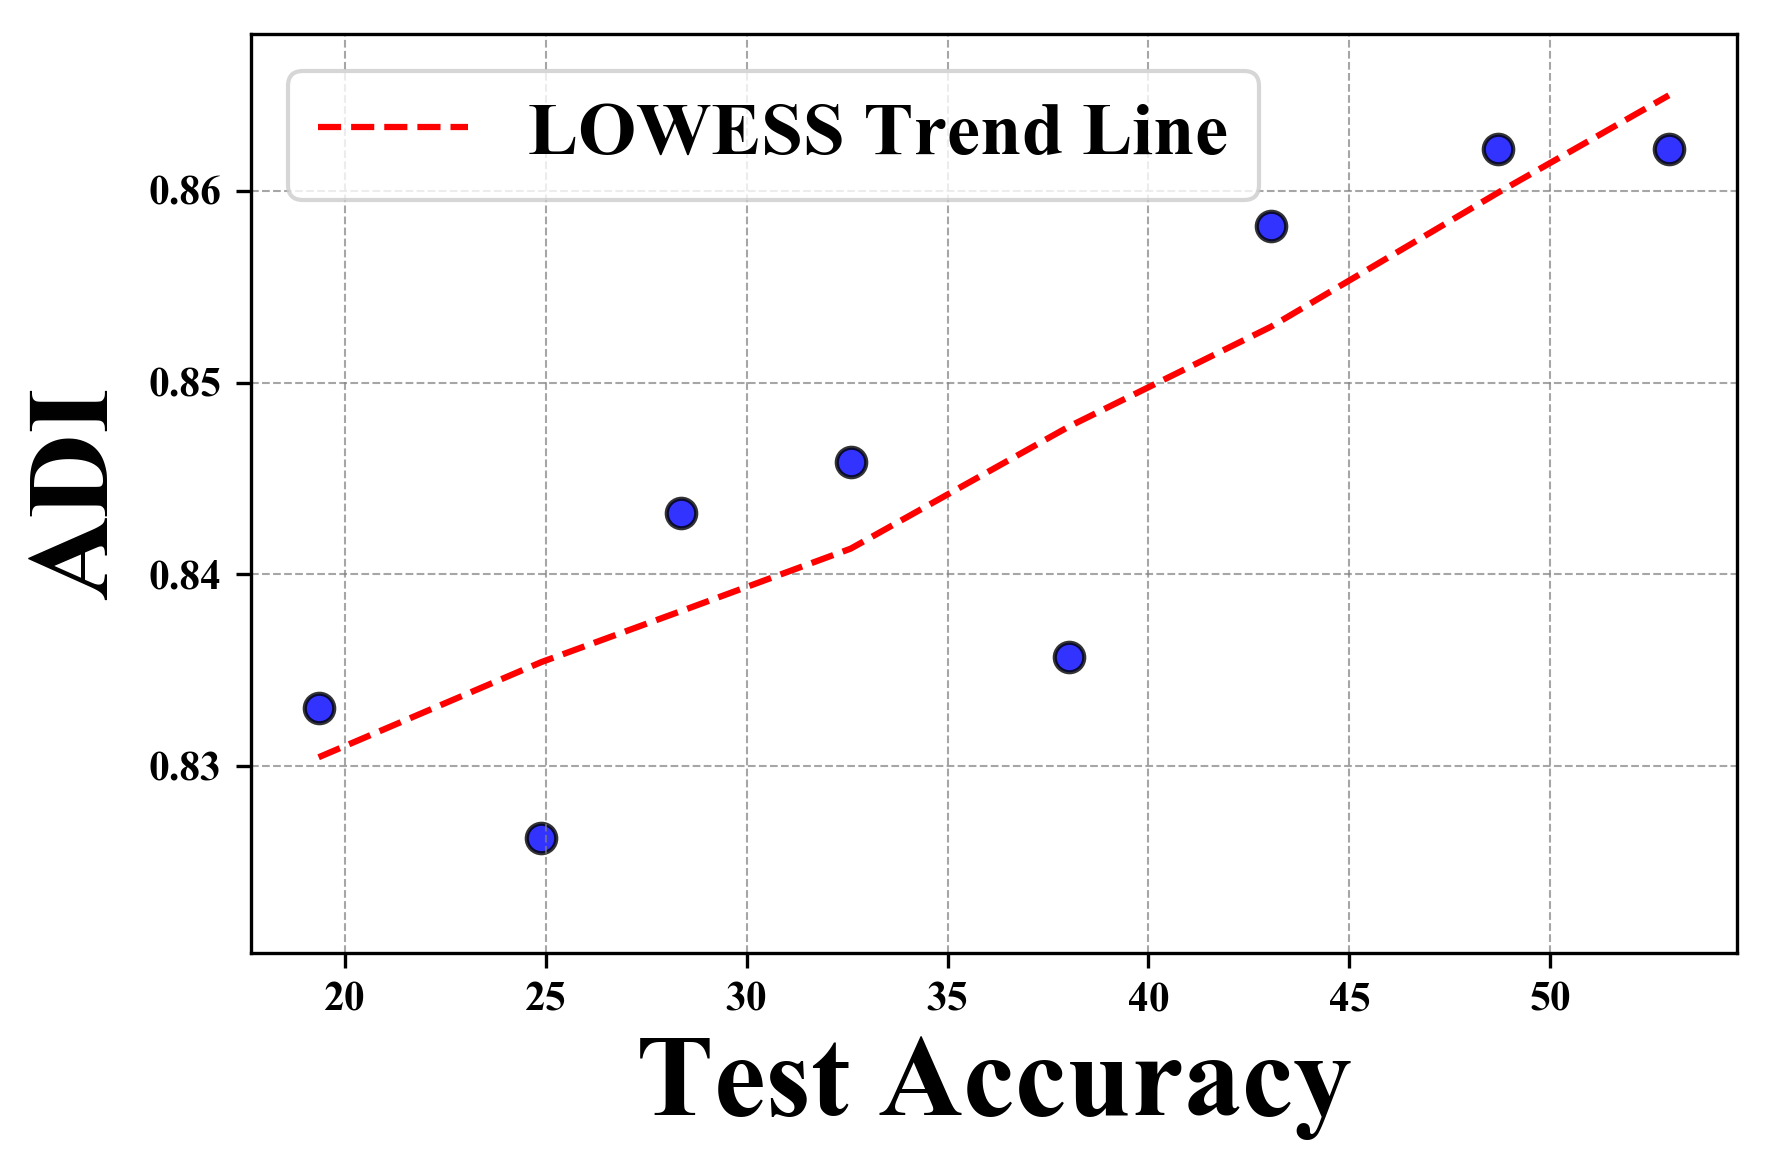

In [42]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import statsmodels.api as sm

# Ensure data is in numpy arrays for compatibility
indegrees = np.array(indegrees)
accuracies = np.array(accuracies)*2.5

# Set the font to Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'

# Create figure and axis with high resolution
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Create scatter plot with professional styling
scatter = ax.scatter(
    accuracies,
    indegrees,
    s=50,                        # Marker size
    c='blue',                    # Marker color
    edgecolor='black',           # Marker edge color
    alpha=0.8,                   # Transparency
    marker='o'                   # Marker style
)

# Fit and plot a LOWESS trend line
lowess = sm.nonparametric.lowess(indegrees, accuracies, frac=0.8)
ax.plot(lowess[:, 0], lowess[:, 1], "r--", linewidth=1.5, label='LOWESS Trend Line')

# Add grid with professional styling
ax.grid(
    True,
    which='both',
    linestyle='--',
    linewidth=0.5,
    color='gray',
    alpha=0.7
)
# ax.set_ylim(bottom=0.03)
# Set axis labels with units if applicable
ax.set_xlabel('Test Accuracy', fontsize=28)
ax.set_ylabel('ADI', fontsize=28)

# Set plot title
# ax.set_title('Scatter Plot of ADI vs. Accuracies', fontsize=14, fontweight='bold')

# Customize tick parameters
ax.tick_params(axis='both', which='major', labelsize=10)
ax.tick_params(axis='both', which='minor', labelsize=8)

# Add legend
ax.legend(fontsize=18)

# Tight layout for better spacing
plt.tight_layout()

# Save the figure in high resolution
plt.savefig(folder_path+ '_labelnoise.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()
